c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


Global mean for IR_bigram_esidaine: 16.638322


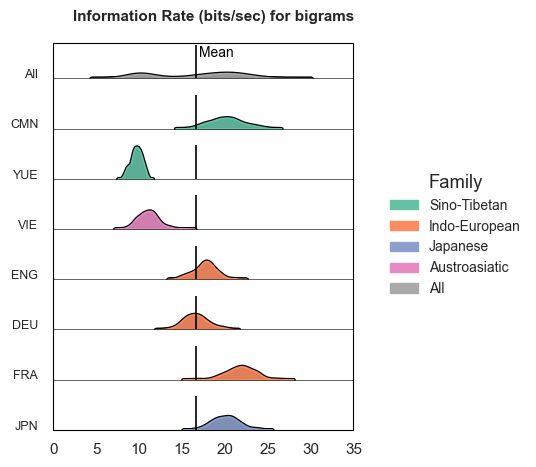

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

def IR_histogram(IR_type):
    """
    Function to plot histograms of Information Rate (IR) across languages.
    """ 

    # Load data
    df_IR = pd.read_csv(
        "C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/produced_data/ling_unit_comparison.csv",
        encoding="utf-8",
        sep=","
    )

    # Clean column names
    df_IR.columns = df_IR.columns.str.strip()

    assert IR_type in df_IR.columns, f"{IR_type} not found in df_IR columns"

    # Filter for selected languages
    languages = ["FRA", "JPN", "CMN", "VIE", "YUE", "ENG", "DEU"]
    df_IR = df_IR[df_IR["Language"].isin(languages)]

    # Map language families
    df_IR["Family"] = df_IR["Language"].map({
        "FRA": "Indo-European",
        "JPN": "Japanese",
        "CMN": "Sino-Tibetan",
        "VIE": "Austroasiatic",
        "YUE": "Sino-Tibetan",
        "ENG": "Indo-European",
        "DEU": "Indo-European"
    })

    # Prepare tidy data
    df_sn = df_IR[["Language", "Family", IR_type]].dropna()
    df_sn = df_sn.rename(columns={IR_type: "Value"})


    # add alpha column (e.g., for plotting transparency)
    df_sn["alpha"] = 0.1

    xlim_dict = {
        "IR_unigram_esidaine": (15, 75),
        "IR_bigram_esidaine": (0, 35),
        "IR_trigram_esidaine": (0, 15),
        "IR_quadgram_esidaine": (0, 8)
    }
    xlim = xlim_dict.get(IR_type, (10, 65))  

    ngram_label = IR_type.split("_")[1] + "s"

    # Prepare the data
    df_sn = df_IR[df_IR['Language'] != 'All']
    df_sn = df_sn.melt(id_vars=['Language', 'Family'], 
                    value_vars=[IR_type], 
                    var_name='Metric', value_name='Value')
    df_sn = df_sn[df_sn['Metric'] == IR_type].dropna()

    # Add aggregated "All" row
    all_data = df_sn.copy()
    all_data["Language"] = "All"
    all_data["Family"] = "All"
    df_sn = pd.concat([df_sn, all_data], axis=0, ignore_index=True)

    # Ensure all levels are retained by making Language categorical AFTER concat
    ordered_languages = ["All", "CMN", "YUE", "VIE", "ENG", "DEU", "FRA", "JPN"]
    df_sn["Language"] = pd.Categorical(df_sn["Language"], categories=ordered_languages, ordered=True)

    # Setup seaborn
    sns.set(style="white", font_scale=1.1)

    # Create color palette by Family
    unique_families = df_sn['Family'].dropna().unique()

    custom_palette = sns.color_palette("Set2", n_colors=len(unique_families))
    palette_dict = {fam: color for fam, color in zip(unique_families, custom_palette)}
    palette_dict["All"] = "#A9A9A9"   # Dark grey color for "All"
    df_sn["Color"] = df_sn["Family"].map(palette_dict)

    # Plot
    g = sns.FacetGrid(df_sn, row="Language", hue="Family", aspect=5, height=0.8, 
                    palette=palette_dict, margin_titles=True)

    # KDE per language
    def kde_with_outline(data, color, **kwargs):
        # Draw thick black outline first
        sns.kdeplot(data=data, x="Value", fill=True, color="black", alpha=1.0,
                    linewidth=3.0, **kwargs)
        # Then overlay the colored KDE
        sns.kdeplot(data=data, x="Value", fill=True, color=color, alpha=0.9,
                    linewidth=1.2, **kwargs)

    g.map_dataframe(kde_with_outline)

    # Draw KDE boundaries and mean
    def draw_one_vertical_line_in_each_axis(global_mean):
        for i, ax in enumerate(g.axes.flat):
            # Only draw in the leftmost axis (row "All")
            if i == 0:
                ax.axvline(global_mean, color='black', linestyle='-', linewidth=1.2)
                ax.text(global_mean + 0.3, 0.55, "Mean",
                        transform=ax.get_xaxis_transform(),
                        fontsize=10, color='black', weight='light',
                        ha='left', va='bottom')
            else:
                ax.axvline(global_mean, color='black', linestyle='-', linewidth=1.2)
    # Set dynamic xlim for all axes
    for ax in g.axes.flat:
        ax.set_xlim(*xlim)

    global_mean = df_IR[df_IR['Language'] != 'All'][IR_type].mean()
    print(f"Global mean for {IR_type}: {global_mean:.6f}")
    draw_one_vertical_line_in_each_axis(global_mean)

    g.set_titles(row_template="{row_name}", col_template="", size=10)

    # Remove vertical facet labels (the default row labels)
    for ax in g.axes[:, 0]:  # Only need to do this for one column
        if hasattr(ax, 'get_ylabel'):
            ax.set_ylabel("")

    for ax, label in zip(g.axes.flat, df_sn['Language'].cat.categories):
        ax.text(-0.05, 0.1, label, transform=ax.transAxes,
                fontsize= 9 , va='center', ha='right', rotation=0)

        
    # Remove default right-side facet titles
    g.set_titles(row_template="")  # Removes default titles

    # Hide all y-ticks and labels
    for ax in g.axes.flat:
        ax.set_ylabel("")
        ax.set_yticks([])

    for ax in g.axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)


    xtick_vals = list(range(xlim[0], xlim[1] + 1, 5))
    g.set(yticks=[], ylabel="")
    g.set(xticks=xtick_vals, xlabel="")
    g.set_xticklabels([str(x) for x in xtick_vals], fontsize=11)
    g.despine(left=True, bottom=False)
    plt.subplots_adjust(hspace=0.5, left=0.1, right=0.85)
    plt.suptitle(f"Information Rate (bits/sec) for {ngram_label}", fontsize=11, fontweight='bold', y=0.95)

    # Create a square-based legend with border
    legend_handles = [
        mpatches.Patch(color=palette_dict[f], label=f) for f in palette_dict
    ]
    legend = g.fig.legend(
        handles=legend_handles,
        title="Family",
        loc='center right',
        bbox_to_anchor=(1.3, 0.5),
        frameon=False, 
        edgecolor='black', 
        fontsize = '10'
    )
    g.fig.set_size_inches(4, 5) 

    # Add rectangle around the figure area
    g.figure.patches.append(Rectangle(
        (0.1, 0.11), 0.75, 0.774,  # (x,y), width, height in figure coordinates
        linewidth=0.8, edgecolor='black', facecolor='none',
        transform=g.figure.transFigure, clip_on=False
    ))
    plt.savefig(f"C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/images/IR_across_Languages_{ngram_label}.png", dpi=300, bbox_inches='tight')
    plt.show()

IR_histogram("IR_bigram_esidaine")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from helpers import check_expected_values

def plot_inforate_vs_ngram_order(text_type):
    """
    Plot Information Rate vs. N-gram Order for different languages and linguistic units.
    Both syllables and phones appear as different lines in the same plot.
    
    Parameters:
    text_type (str): Either "within_words" or "across_sentences"
    """
    
    # Load and filter
    df = pd.read_csv(
        "produced_data/inter_intra_comparison.csv",
        encoding="utf-8",
        sep=","
    )
    
    df.columns = df.columns.str.strip()
    languages = ['DEU'] # Change as needed
    df = df[df["Language"].isin(languages)]

    processing_types = ["sylls", "phones", 'words']
        
    # Check for data coverage 
    if not check_expected_values(df):
        print("Data coverage check failed. Ensure all expected values are present.")
        return
    
    # Set style
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(10, 6))
    
    # Collect all data for both processing types
    all_data = []
    
    # Specify processing types
    for processing_type in processing_types: 
        
        # Find IR columns for this processing type and text type
        IR_cols = [col for col in df.columns 
                   if col.startswith(text_type) 
                   and processing_type in col 
                   and "IR_" in col]
        
        
        print(f"\nProcessing {processing_type} for {text_type}:")
        print(f"Found IR columns: {IR_cols}")
        
        if not IR_cols:
            print(f"No IR columns found for {processing_type} and {text_type}")
            continue
            
        # Prepare data
        df_IR = df[["Language"] + IR_cols].copy()
        df_IR_long = df_IR.melt(id_vars="Language", var_name="Metric", value_name="IR")
        
        # Extract n-gram order
        df_IR_long["n"] = df_IR_long["Metric"].str.extract(r"IR_(unigram|bigram|trigram|quadgram)")
        ngram_order = {"unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4}
        df_IR_long["n"] = df_IR_long["n"].map(ngram_order)
        
        # Remove rows where n-gram order extraction failed
        df_IR_long = df_IR_long.dropna(subset=['n'])

        # CHECK: Print ID and IR values for this linguistic unit
        print(f"\n=== {processing_type.upper()} VALUES ===")
        print(f"Sample IR values by n-gram order:")
        for n in [1, 2, 3, 4]:
            subset = df_IR_long[df_IR_long["n"] == n]
            if not subset.empty:
                print(f"  N-gram {n}: IR range = {subset['IR'].min():.2f} to {subset['IR'].max():.2f}")
                print(f"    Mean IR = {subset['IR'].mean():.2f}")
        
        # Also print first few rows to see the actual data
        print(f"\nFirst rows of {processing_type} data:")
        print(df_IR_long[:25])
        
        if df_IR_long.empty:
            print(f"No valid data for {processing_type}")
            continue
        
        # Add linguistic unit information
        df_IR_long["Linguistic_Unit"] = processing_type.title()
        
        # Create combined language-unit identifier for plotting
        df_IR_long["Language_Unit"] = df_IR_long["Language"] + " (" + df_IR_long["Linguistic_Unit"] + ")"
        
        all_data.append(df_IR_long)
    
    # Combine all data
    if not all_data:
        print("No valid data found for any processing type")
        return
    
    df_combined = pd.concat(all_data, ignore_index=True)
    
    # Alphabetical order of legend entries
    df_combined = df_combined.sort_values(by=["Language_Unit", "n"])
    ordered_labels = df_combined["Language_Unit"].drop_duplicates().tolist()
        
    # Create color palette - different colors for languages, different styles for units
    languages_units = df_combined["Language_Unit"].unique()
    custom_palette = sns.color_palette("Set2", n_colors=len(languages_units))
    
    # Plot all lines
    sns.lineplot(
        data=df_combined,
        x="n", y="IR",
        hue="Language_Unit", hue_order=ordered_labels,
        palette=custom_palette,
        linewidth=2, alpha=0.85, linestyle="-"
    )
    
    # Add mean lines for each linguistic unit
    for processing_type in processing_types:
        df_unit = df_combined[df_combined["Linguistic_Unit"] == processing_type]
        if not df_unit.empty:
            df_mean = df_unit.groupby("n", as_index=False)["IR"].mean()
            
            # Use different colors/styles for different unit means
            color = "darkred" if processing_type == "Sylls" else "darkblue"
            linestyle = "--" if processing_type == "Sylls" else ":"
            
            sns.lineplot(data=df_mean, x="n", y="IR", color=color, 
                        label=f"{processing_type} Mean", linewidth=3, linestyle=linestyle)
            
            # Annotate mean values
            for i, row in df_mean.iterrows():
                plt.text(row["n"] + 0.05, row["IR"] + 0.04, f"{row['IR']:.2f}",
                       color=color, fontsize=11, fontweight='bold')
    
    # Customize plot
    plt.title(f"Information Rate for Different Unit Types - {text_type.title()} Level", 
              fontsize=15, weight='bold', pad=15)
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language (Unit - Text Type)", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(f"images/IR_vs_ngram_order_{text_type}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()


plot_inforate_vs_ngram_order("words")
#plot_inforate_vs_ngram_order("sentences")

TypeError: check_expected_values() takes 1 positional argument but 2 were given

In [5]:
import pandas as pd

# Load and filter data
df = pd.read_csv("produced_data/inter_intra_comparison.csv", encoding="utf-8", sep=",")
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains('_4gram')]
df.columns
df.to_csv("produced_data/inter_intra_comparison.csv", index=False)


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from helpers import check_expected_values


def plot_inforate_combined_texttypes(languages, processing_types):
    """
    Plot Information Rate vs. N-gram Order for both words and sentences in a single plot.
    Each line = unique combination of language, processing type, and text level.
    Adds mean line for each processing type + text level.
    """

    # Load and filter data
    df = pd.read_csv("produced_data/inter_intra_comparison.csv", encoding="utf-8", sep=",")
    df.columns = df.columns.str.strip()
    df = df[df["Language"].isin(languages)]


    # Check for data coverage 
    if not check_expected_values(df):
        print("Data coverage check failed. Ensure all expected values are present.")
        return


    all_data = []

    print(f"\nProcessing types: {processing_types}")
    for text_type in ["within_words", "across_sentences"]:
        for processing_type in processing_types:
            IR_cols = [col for col in df.columns if col.startswith(text_type) and processing_type in col and "IR_" in col]
            if not IR_cols:
                continue
            df_IR = df[["Language"] + IR_cols].copy()
            df_IR_long = df_IR.melt(id_vars="Language", var_name="Metric", value_name="IR")
            df_IR_long["n"] = df_IR_long["Metric"].str.extract(r"IR_(unigram|bigram|trigram|quadgram)")
            df_IR_long["n"] = df_IR_long["n"].map({"unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4})
            df_IR_long = df_IR_long.dropna(subset=["n"])
            df_IR_long["Linguistic_Unit"] = processing_type.title()
            df_IR_long["Text_Level"] = text_type.title()
            df_IR_long["Label"] = df_IR_long["Language"] + " (" + df_IR_long["Linguistic_Unit"] + " - " + df_IR_long["Text_Level"] + ")"
            all_data.append(df_IR_long)

    if not all_data:
        print("No valid data found.")
        return

    df_combined = pd.concat(all_data, ignore_index=True)

    # Generate ordered labels for legend
    df_combined = df_combined.sort_values(by="Language")
    ordered_labels = df_combined["Label"].drop_duplicates().tolist()

    # Style and figure setup
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(11, 6))

    # Create color palette
    unique_labels = df_combined["Label"].unique()
    custom_palette = sns.color_palette("Set2", n_colors=len(unique_labels))

    # Plot individual lines as solid lines
    sns.lineplot(
        data=df_combined, x="n", y="IR", hue="Label",
        hue_order=ordered_labels, style_order=ordered_labels,
        palette=custom_palette, linewidth=2, alpha=0.85, linestyle="-"
    )

    # Add mean lines per processing type and text level
    for processing_type in processing_types:
        for text_level in ['within_words', 'across_sentences']:
            df_unit = df_combined[
                (df_combined["Linguistic_Unit"] == processing_type) &
                (df_combined["Text_Level"] == text_level)
            ]
            if not df_unit.empty:
                df_mean = df_unit.groupby(["Language", "n"], as_index=False)["IR"].mean()
                df_mean = df_mean.groupby("n", as_index=False)["IR"].mean()
  
                # Set distinct color + style per type
                if processing_type == "Sylls":
                    color = "darkred" if text_level == "Words" else "firebrick"
                    linestyle = "--"
                else:
                    color = "darkblue" if text_level == "Words" else "royalblue"
                    linestyle = ":"

                sns.lineplot(data=df_mean, x="n", y="IR", color=color,
                             label=f"{processing_type} Mean ({text_level})", linewidth=3, linestyle=linestyle)

                for _, row in df_mean.iterrows():
                    plt.text(row["n"] + 0.05, row["IR"] + 0.04, f"{row['IR']:.2f}",
                             color=color, fontsize=11, fontweight='bold')

    # Customize plot
    plt.title("Information Rate vs. N-gram Order \n Within Word vs. Across Sentence Level",
              fontsize=15, weight='bold', pad=15)
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language (Unit - Text Type)", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()

    # Save and show
    plt.savefig("images/IR_vs_ngram_order_within_words_across_sentences.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_inforate_combined_texttypes(languages=["FRA", "DEU"], processing_types=["phones"])


✅ Total expected columns: 60
✅ Total actual columns: 57

❌ Missing columns:
  - across_sentences_sylls_ID_quadgram
  - across_sentences_sylls_IR_quadgram
  - across_sentences_sylls_SR_quadgram

⚠️ Columns present but entirely empty (all NaN), per language:
  FRA:
    - across_sentences_phones_ID_bigram
    - across_sentences_phones_ID_trigram
    - across_sentences_phones_IR_bigram
    - across_sentences_phones_IR_trigram
    - across_sentences_phones_SR_bigram
    - across_sentences_phones_SR_trigram
    - across_sentences_sylls_ID_bigram
    - across_sentences_sylls_ID_trigram
    - across_sentences_sylls_IR_bigram
    - across_sentences_sylls_IR_trigram
    - across_sentences_sylls_SR_bigram
    - across_sentences_sylls_SR_trigram
    - within_words_phones_ID_bigram
    - within_words_phones_ID_trigram
    - within_words_phones_IR_bigram
    - within_words_phones_IR_trigram
    - within_words_phones_SR_bigram
    - within_words_phones_SR_trigram
    - within_words_sylls_ID_bigram
  

C:\Users\emill\AppData\Local\Temp\ipykernel_20144\849287231.py:36: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df_IR_long, x="n", y="IR", hue="Language",


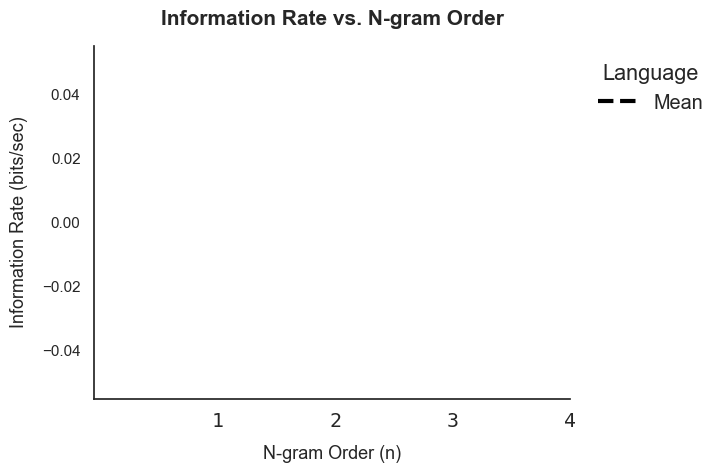

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_inforate_vs_ngram_order():
    """
    Plot Information Rate vs. N-gram Order for different languages (line plot).
    """

    # Load and filter
    df_IR = pd.read_csv(
        "syll_comparison_coupe_esidaine.csv",
        encoding="utf-8",
        sep=","
    )
    df_IR.columns = df_IR.columns.str.strip()
    languages = ["FRA", "JPN", "CMN", "VIE", "YUE", "ENG", "DEU"]
    df_IR = df_IR[df_IR["Language"].isin(languages)]

    # Prepare data
    ir_cols = [col for col in df_IR.columns if col.startswith("IR_") and "esidaine" in col]
    df_ir = df_IR[["Language"] + ir_cols].copy()
    df_IR_long = df_ir.melt(id_vars="Language", var_name="Metric", value_name="IR")
    df_IR_long["n"] = df_IR_long["Metric"].str.extract(r"IR_(unigram|bigram|trigram|quadgram)")
    ngram_order = {"unigram": 1, "bigram": 2, "trigram": 3, "quadgram": 4}
    df_IR_long["n"] = df_IR_long["n"].map(ngram_order)

    # Set style
    sns.set_context("notebook", font_scale=1.3)
    sns.set_style("white")
    plt.figure(figsize=(7.5, 5))

    # Custom color palette
    custom_palette = sns.color_palette("Set2", n_colors=len(languages))
    sns.lineplot(data=df_IR_long, x="n", y="IR", hue="Language",
                palette=custom_palette, linewidth=2, alpha=0.85)

    # Add mean line
    df_mean = df_IR_long.groupby("n", as_index=False)["IR"].mean()
    sns.lineplot(data=df_mean, x="n", y="IR", color="black", label="Mean",
                linewidth=3, linestyle='--')

    # Annotate mean
    for i, row in df_mean.iterrows():
        plt.text(row["n"] + 0.05, row["IR"] + 0.04, f"{row['IR']:.2f}",
                color='black', fontsize=11, fontweight='bold')

    # Final plot tweaks
    plt.title("Information Rate vs. N-gram Order", fontsize=15, weight='bold', pad=15)
    plt.xlabel("N-gram Order (n)", fontsize=13, labelpad=10)
    plt.ylabel("Information Rate (bits/sec)", fontsize=13, labelpad=10)
    plt.xticks([1, 2, 3, 4], labels=["1", "2", "3", "4"], family="monospace")
    plt.yticks(fontsize=11)
    plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/images/IR_vs_ngram_order.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_inforate_vs_ngram_order()

plot_inforate_vs_ngram_order()

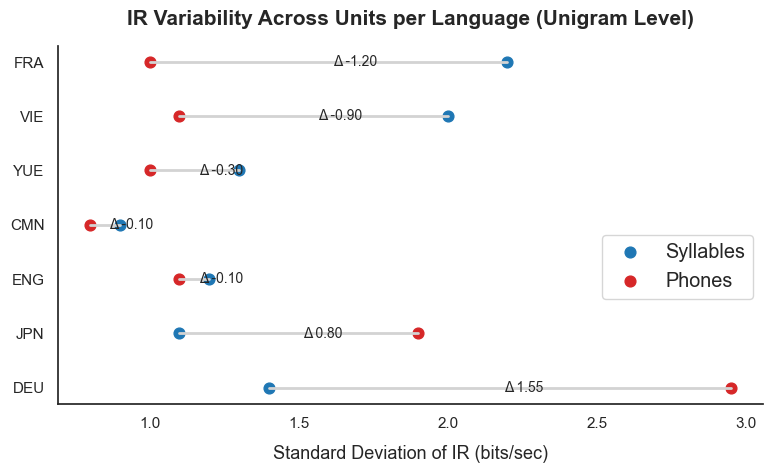

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare consistent style
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")

# Example data
df_std = pd.DataFrame({
    "Language": ["FRA", "DEU", "JPN", "CMN", "VIE", "YUE", "ENG"] * 2,
    "Unit": ["sylls"] * 7 + ["phones"] * 7,
    "Std_IR": [2.2, 1.4, 1.1, 0.9, 2.0, 1.3, 1.2,
               1.0, 2.95, 1.9, 0.8, 1.1, 1.0, 1.1]
})

# Pivot and compute delta
pivot_std = df_std.pivot(index="Language", columns="Unit", values="Std_IR").reset_index()
pivot_std["Delta"] = pivot_std["phones"] - pivot_std["sylls"]
pivot_std = pivot_std.sort_values("Delta", ascending=False)

# Plot setup
plt.figure(figsize=(8, 5))
custom_colors = {"sylls": "#1f77b4", "phones": "#d62728"}

# Draw dumbbells
for i, row in pivot_std.iterrows():
    plt.plot([row["sylls"], row["phones"]], [row["Language"]] * 2, color="lightgray", linewidth=2)
    plt.scatter(row["sylls"], row["Language"], color=custom_colors["sylls"], s=60, label="Syllables" if i == 0 else "")
    plt.scatter(row["phones"], row["Language"], color=custom_colors["phones"], s=60, label="Phones" if i == 0 else "")
    plt.text((row["sylls"] + row["phones"]) / 2 + 0.015, row["Language"],
             f"Δ {row['Delta']:.2f}", va='center', ha='left', fontsize=10)

# Titles and labels
plt.title("IR Variability Across Units per Language (Unigram Level)", fontsize=15, weight='bold', pad=15)
plt.xlabel("Standard Deviation of IR (bits/sec)", fontsize=13, labelpad=10)
plt.ylabel("")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(bbox_to_anchor=(1, 0.5), loc='upper right', frameon=True)

# Final styling
sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()


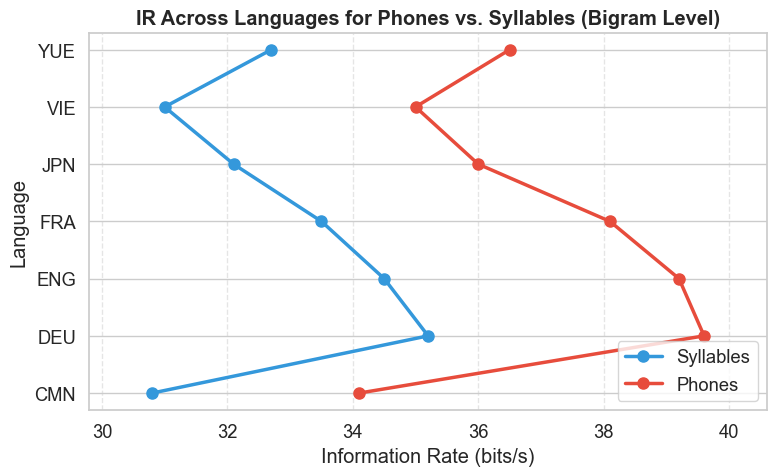

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use a visually appealing style
sns.set(style="whitegrid", context="notebook", font_scale=1.2)

# Example data 
df_ir = pd.DataFrame({
    "Language": ["FRA", "DEU", "JPN", "CMN", "VIE", "YUE", "ENG"] * 2,
    "Unit": ["sylls"] * 7 + ["phones"] * 7,
    "Ngram": ["unigram"] * 14,
    "IR": [33.5, 35.2, 32.1, 30.8, 31.0, 32.7, 34.5,
           38.1, 39.6, 36.0, 34.1, 35.0, 36.5, 39.2]
})

# Filter to unigram level only
df_uni = df_ir[df_ir["Ngram"] == "unigram"]

# Separate data by unit and sort by language name (for consistent Y-axis)
df_sylls = df_uni[df_uni["Unit"] == "sylls"].sort_values("Language")
df_phones = df_uni[df_uni["Unit"] == "phones"].sort_values("Language")
languages = df_sylls["Language"].values

# Plot
plt.figure(figsize=(8, 5))
plt.plot(df_sylls["IR"], languages, '-o', color='#3498db', linewidth=2.5, markersize=8, label="Syllables")
plt.plot(df_phones["IR"], languages, '-o', color='#e74c3c', linewidth=2.5, markersize=8, label="Phones")

# Styling
plt.xlabel("Information Rate (bits/s)")
plt.ylabel("Language")
plt.title("IR Across Languages for Phones vs. Syllables (Bigram Level)", weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(min(df_uni["IR"]) - 1, max(df_uni["IR"]) + 1)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

